# Respiratory rate estimation

### Description

Seismocardiography([SCG](https://www.ncbi.nlm.nih.gov/pubmed/24111357) is a very promising technique to measure Heart Rate (HR) and Respiratory Rate (RR) with the detector positioned above sternum. It is generally based on accelerometer and gyroscope readings or a combination of them.
Ballistocardiography([BCG](https://en.wikipedia.org/wiki/Ballistocardiography)) is an another technique to estimate heart and respiratory rate with combination of both accelerometer and gyroscope. It is an indirect evaluation of HR and RR since the contact between the device and the body of the subject is not required (e.g., accelerometer platform mounted under the slats of the bed).
MuSe(Multi-Sensor miniaturized, low-power, wireless [IMU](https://en.wikipedia.org/wiki/Inertial_measurement_unit)) is an Inertial Measurement Unit (IMU) provide by (221e)[https://www.221e.com]. In the context of this project, It allows to record the inertial data necessary for the estimation of SCG and BCG.
The goal of this assignment is to estimate the respiratory rate of an healthy subject, given linear acceleration and angular velocity measurements recorded by using the aforementioned MuSe platform. The study must be performed on two datasets: the first is the compulsory one (center_sternum.txt) while the second is left at the discretion of the group, among those made available for the assignment.
N.B: Remember that normal beat is around 40-100 bpm.

[Actigraphy](https://en.wikipedia.org/wiki/Actigraphy) is a non-invasive method of monitoring human rest/activity cycles. Data will be provided from sensors gathering data on humans during their day/night activities

### Datasets

The data is provided in .txt file. During this study two healthy subjects were involved with their informed consent. The first dataset was recorded on one subject, while all the other datasets were recorded on the second subject.

This is the first mandatory file:
* center_sternum.txt: MuSe placed on the center of the sternum. The subject was lying supine on his left and right side, respectively.

Choose one of the following files in order to complete the task.
1. 1_Stave_supine_static.txt: Sensor placed on a bed stave, under the mattress at the level of the chest. The subject was lying supine on his left and right side.
2. 2_Mattress_supine.txt: Sensor placed on the mattress, near one corner but not under the pillow. The subject laid in the same position as above.
3. 3_Subject_sitting_chair.txt: Sensor placed on the desk: the subject, sitting on a chair, leaned forearms and hands on the desk.
4. 4_Chest_sweater.txt: Sensor placed on the subject chest directly on a sweater.
5. 5_Under_chair.txt: Subject sitting on a chair, sensor placed under the seat of the chair.

All .txt files give 16 columns index, in particular:
* Log Freq stands for the acquisition in Hz (i.e., sampling interval is constant).
* AccX, AccY, AccZ are the measured magnitude of linear acceleration along each axis.
* GyroX, GyroY, GyroZ are the measured magnitude of angular velocity along each axis.
* MagnX, MagnY, MagnZ are the measured magnitude of magnetic field along each axis.
* qw, qi, qj, qk are the quaternion components, representing the spatial orientation of the Muse
system.

Each dataset includes, in addition to the data, one file containing the adopted configuration of the MuSe(README1.txt for the first measurement, and in README_5.txt for the other measurement).
 
### Assignments

Data preparation:

1.1. Load the txt file and select only the columns you are interesting in, in order to do a complete data analysis (e.g. Log Freq, AccX, ... )

1.2. Plot selected data in function of time and choose a properly time window over which to perform the analysis. Pay attention on time rappresentation and the measurament unit.

1.3. In order to make an appropiate work, decide if take care about some particular axis or some combination of them as well as derived features for the next step of the task. Motivate your choice.

Time and frequency analysis:

2.1. Statistical analysis: provide a statistical description of the chosen dataset. Statistical
descriptors includes for example mean, median, variance, standard deviation, 25th and 75th percentiles, and correlation coefficients. Investigate what could be the most interesting descriptors for this type of data, motivating the choices.

2.2. Fourier Analysis: Perform a frequency analysis of the data. Look at the spectrum and explain what you see. Use this step in order to properly design the filters in the following step.

Filter:

Implement your own filter, trying to extrapolate respiratory rate signal. Hint:

(a) Directly from Fourier Analysis, antitrasform data looking for the most interesting frequency band.

(b) Choose the appropriate Lowpass/Bandpass/Highpass filter.

(c) Wavelet trasform (a powerfull instrument that make a time and frequency analysis of signal). (d) Find another method by yourselves.

Motivate your choice.

Metrics:

4.1. Respiratory Rate Per Minute(RPM): extrapolate RPM, make an histogram of the result. Does it follow a partiular distribution?

4.2. Respiratory Rate Variability(RRV): extrapolate RRV, explain why this parameter is important, and plot the results.

(OPTIONAL) Algorithm: Elaborate a simple algorithm to extrapolate respiratory rate even when filter failed (e.g. look at particular threshold...).

Conclusion:
 Summarise the obtained results, in particular making a comparison between the two files analysed. Highlight limitation and critical issues encountered during the work, motivating the most relevant contribution given by your solution.

N.B: Indicate the contribution, to achieving the result, of each member of the group.

 

### Contacts

* Marco Zanetti <marco.zanetti@unipd.it>
* Marco Signorelli <signo@221e.com>



In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def convertTime(lendata, rate=200):
    time = np.arange(lendata) / rate
    return time

def calibration(data, bias, matrix=None):
    if matrix is None:
        return data - bias
    calibrated_data = np.dot(matrix, (data).T).T + bias
    return calibrated_data

df = pd.read_csv('center_sternum.txt', delimiter='\t')
df

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,200,1576222772,947.086,435.662,70.638,-6.824428,-14.244280,1.404580,-454,-490,-178,0.792622,0.254952,-0.553850,-0.000031
1,5,200,1576222772,969.168,387.777,88.877,6.183206,-12.290080,-7.969466,-454,-490,-177,0.736461,0.275124,-0.617969,0.006806
2,5,200,1576222772,989.603,380.335,78.751,11.709920,-4.961832,-7.450382,-454,-490,-177,0.729465,0.275246,-0.626118,0.009827
3,5,200,1576222772,954.894,418.033,88.328,17.877860,2.519084,-5.984733,-454,-492,-176,0.723413,0.277200,-0.632221,0.011383
4,5,200,1576222772,972.096,427.732,99.857,25.221370,5.404580,4.015267,-454,-492,-176,0.721948,0.280007,-0.632679,0.010193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16501,5,200,1576222847,958.493,291.092,-54.290,1.664122,2.305344,-0.671756,-494,-449,-126,0.650810,0.379162,-0.636402,0.166356
16502,5,200,1576222847,954.650,288.042,-49.654,1.480916,2.488550,-0.702290,-494,-450,-125,0.650239,0.379803,-0.636708,0.165960
16503,5,200,1576222847,967.338,290.482,-63.867,1.114504,3.374046,-0.900763,-494,-450,-125,0.649365,0.380627,-0.637227,0.165502
16504,5,200,1576222847,965.630,300.852,-56.242,0.702290,3.664122,-1.587786,-495,-448,-124,0.648973,0.381329,-0.637348,0.164953


82.525


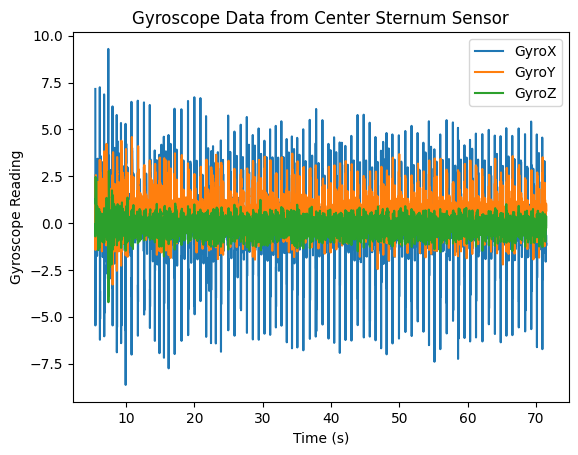

In [37]:
time = convertTime(len(df['Timestamp']), rate=200)
print(time[-1])

df['Time'] = time

offset_gyro = np.array([-2.242224, 2.963463, -0.718397])

df_filtered = df[(df['Time'] > 5.5) & (df['Time'] < 71.5)]
time = df_filtered['Time'].to_numpy()

GyroArray = df_filtered[['GyroX', 'GyroY', 'GyroZ']].to_numpy()

GyroArray = calibration(GyroArray, offset_gyro)
GyroX = GyroArray[:, 0] # degrees per second
GyroY = GyroArray[:, 1]
GyroZ = GyroArray[:, 2]

plt.plot(time, GyroX, label='GyroX')
plt.plot(time, GyroY, label='GyroY')
plt.plot(time, GyroZ, label='GyroZ')
plt.legend()
plt.title('Gyroscope Data from Center Sternum Sensor')
plt.xlabel('Time (s)')
plt.ylabel('Gyroscope Reading')
plt.show()

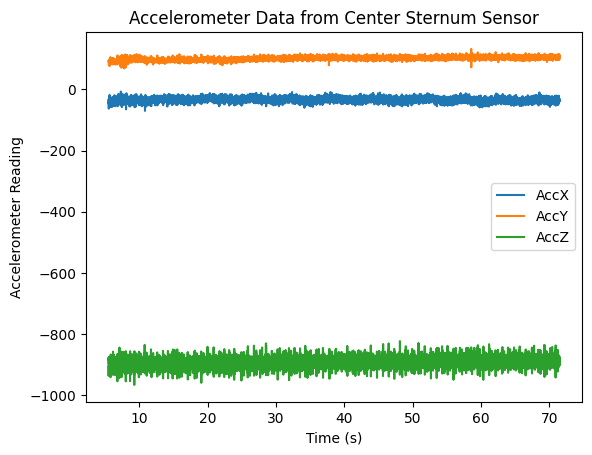

In [38]:
AccArray = df_filtered[['AccX', 'AccY', 'AccZ']].to_numpy()

calibration_matrix_acc = np.array([[1.000966, -0.002326418, -0.0006995499],
                                   [-0.002326379, 0.9787045, -0.001540918],
                                   [-0.0006995811, -0.001540928, 1.00403]])

offset_acc = np.array([-3.929942, -13.74679, 60.67546])

AccArray = calibration(AccArray, offset_acc, calibration_matrix_acc)

AccX = AccArray[:, 0] # unit of mg
AccY = AccArray[:, 1]
AccZ = AccArray[:, 2]
plt.plot(time, AccX, label='AccX')
plt.plot(time, AccY, label='AccY')
plt.plot(time, AccZ, label='AccZ')
plt.legend()
plt.title('Accelerometer Data from Center Sternum Sensor')
plt.xlabel('Time (s)')
plt.ylabel('Accelerometer Reading')
plt.show()

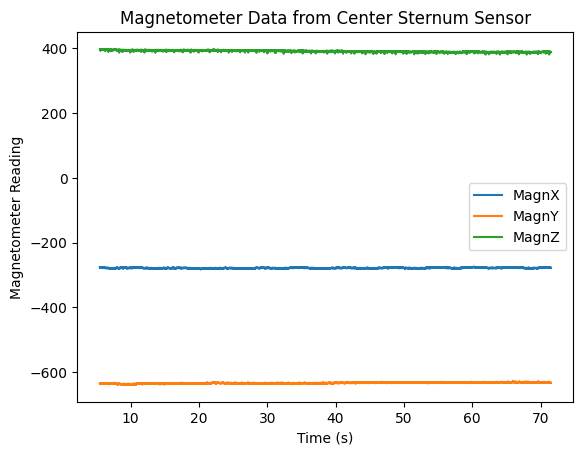

In [39]:
MagnArray = df_filtered[['MagnX', 'MagnY', 'MagnZ']].to_numpy()

calibration_matrix_magn = np.array([[0.9192851, -0.02325168, 0.003480837],
                                    [-0.02325175, 0.914876, 0.004257396],
                                    [0.003481006, 0.004257583, 0.8748001]])

offset_magn = np.array([-95.67974, -244.9142, 17.71132])

MagnArray = calibration(MagnArray, offset_magn, calibration_matrix_magn)

MagnX = MagnArray[:, 0] # milli - gauss
MagnY = MagnArray[:, 1]
MagnZ = MagnArray[:, 2]
plt.plot(time, MagnX, label='MagnX')
plt.plot(time, MagnY, label='MagnY')
plt.plot(time, MagnZ, label='MagnZ')
plt.legend()
plt.title('Magnetometer Data from Center Sternum Sensor')
plt.xlabel('Time (s)')
plt.ylabel('Magnetometer Reading')
plt.show()

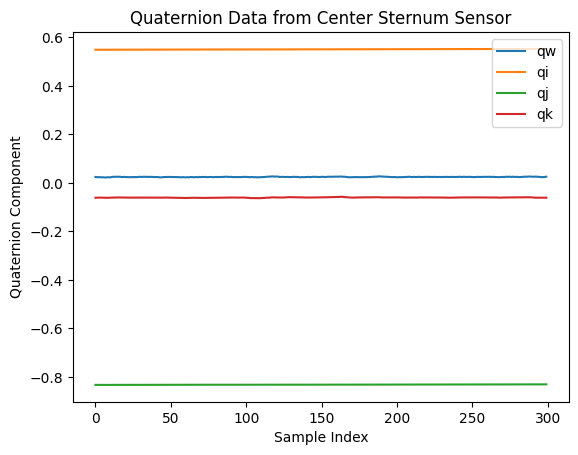

In [40]:
qw = df['qw'][9700:10000]
qi = df['qi'][9700:10000]
qj = df['qj'][9700:10000]
qk = df['qk'][9700:10000]
xaxis = np.arange(0, len(qw), 1)
plt.plot(xaxis, qw, label='qw')
plt.plot(xaxis, qi, label='qi')
plt.plot(xaxis, qj, label='qj')
plt.plot(xaxis, qk, label='qk')
plt.legend()
plt.title('Quaternion Data from Center Sternum Sensor')
plt.xlabel('Sample Index')
plt.ylabel('Quaternion Component')
plt.show()

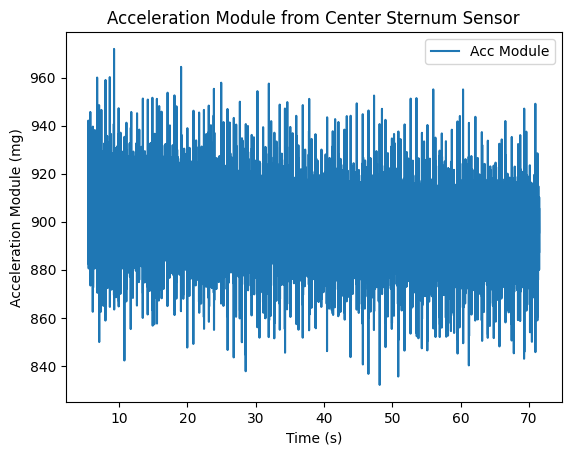

In [41]:
# acceleration module

Acc_module = np.sqrt(AccX**2 + AccY**2 + AccZ**2)
plt.plot(time, Acc_module, label='Acc Module')
plt.legend()
plt.title('Acceleration Module from Center Sternum Sensor')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration Module (mg)')
plt.show()

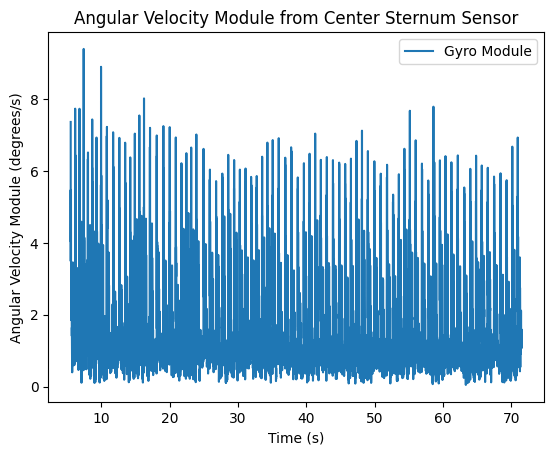

In [42]:
# angular velocity module

Gyro_module = np.sqrt(GyroArray[:, 0]**2 + GyroArray[:, 1]**2 + GyroArray[:, 2]**2)

plt.plot(time, Gyro_module, label='Gyro Module')
plt.legend()
plt.title('Angular Velocity Module from Center Sternum Sensor')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity Module (degrees/s)')
plt.show()

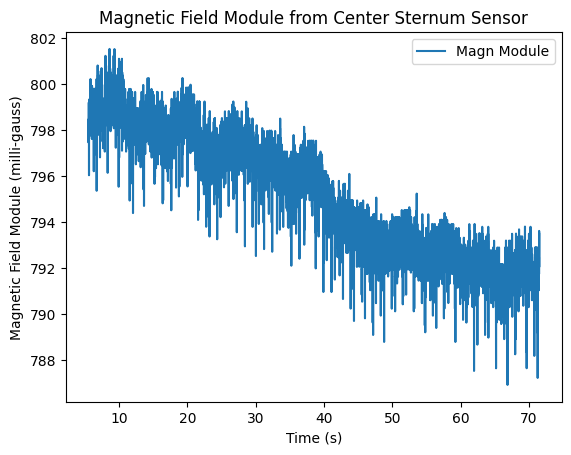

In [43]:
# magnetic field module

Magn_module = np.sqrt(MagnArray[:, 0]**2 + MagnArray[:, 1]**2 + MagnArray[:, 2]**2)
plt.plot(time, Magn_module, label='Magn Module')
plt.legend()
plt.title('Magnetic Field Module from Center Sternum Sensor')
plt.xlabel('Time (s)')
plt.ylabel('Magnetic Field Module (milli-gauss)')
plt.show()

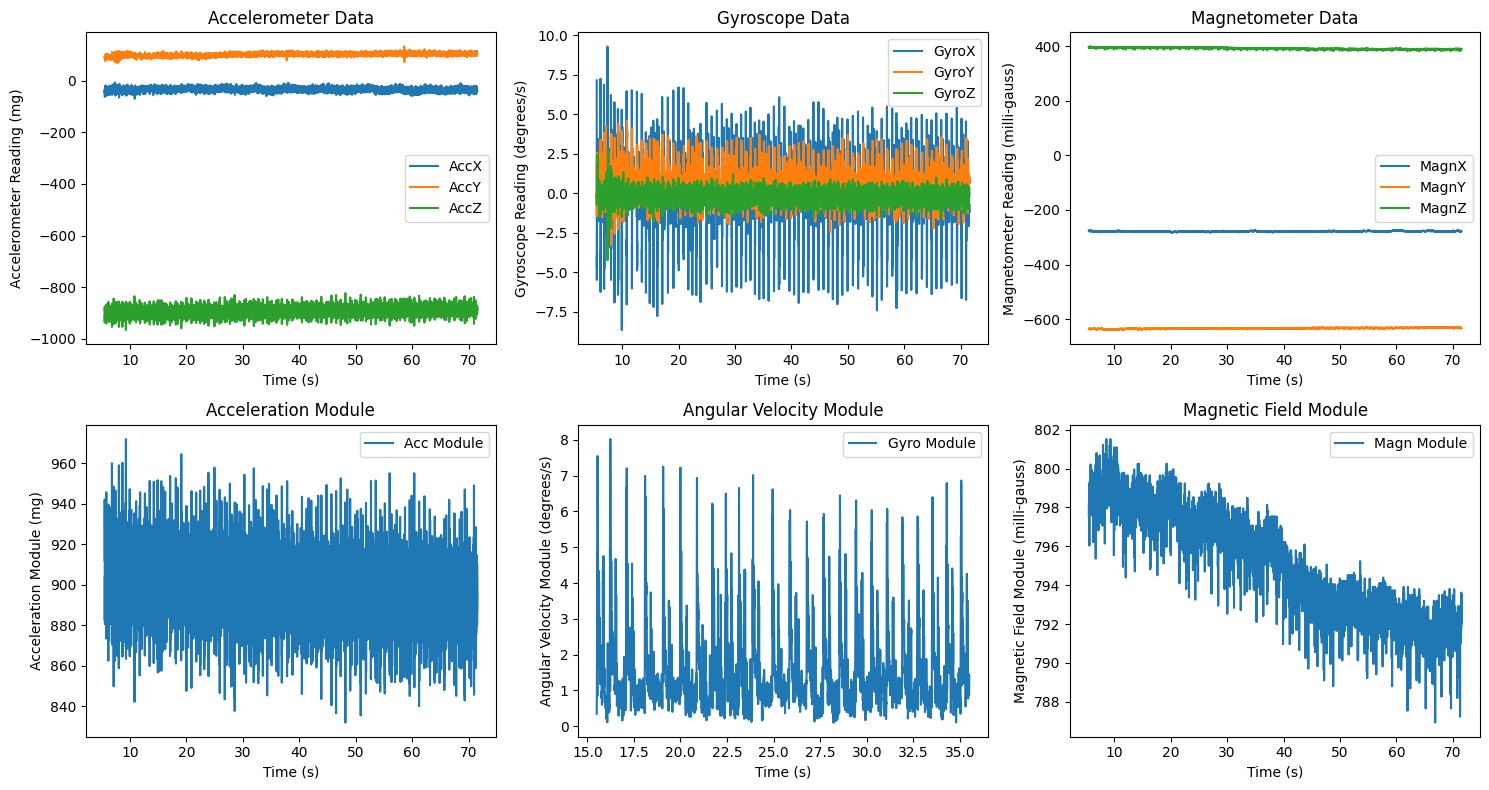

In [50]:
# take all the plots we have done and make a unique plot with lots of subplots, to make a unique visualization of the data from the center sternum sensor.
# make a function that takes df dataframe and time and make all the plots we have done in one unique plot with subplots.

def plot_all_in_one(df, time, mask=None):
    
    GyroArray = df[['GyroX', 'GyroY', 'GyroZ']].to_numpy()
    GyroArray = calibration(GyroArray, offset_gyro)
    GyroX = GyroArray[:, 0] # degrees per second
    GyroY = GyroArray[:, 1]
    GyroZ = GyroArray[:, 2]

    AccArray = df[['AccX', 'AccY', 'AccZ']].to_numpy()
    AccArray = calibration(AccArray, offset_acc, calibration_matrix_acc)
    AccX = AccArray[:, 0] # unit of mg
    AccY = AccArray[:, 1]
    AccZ = AccArray[:, 2]

    MagnArray = df[['MagnX', 'MagnY', 'MagnZ']].to_numpy()
    MagnArray = calibration(MagnArray, offset_magn, calibration_matrix_magn)
    MagnX = MagnArray[:, 0] # milli - gauss
    MagnY = MagnArray[:, 1]
    MagnZ = MagnArray[:, 2]

    '''
    qw = df['qw'][9700:10000]
    qi = df['qi'][9700:10000]
    qj = df['qj'][9700:10000]
    qk = df['qk'][9700:10000]
    '''
    
    Acc_module = np.sqrt(AccX**2 + AccY**2 + AccZ**2)
    Gyro_module = np.sqrt(GyroArray[2000:6000, 0]**2 + GyroArray[2000:6000, 1]**2 + GyroArray[2000:6000, 2]**2)
    Magn_module = np.sqrt(MagnArray[:, 0]**2 + MagnArray[:, 1]**2 + MagnArray[:, 2]**2)

    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    
    axs[0, 0].plot(time, AccX, label='AccX')
    axs[0, 0].plot(time, AccY, label='AccY')
    axs[0, 0].plot(time, AccZ, label='AccZ')
    axs[0, 0].set_title('Accelerometer Data')
    axs[0, 0].set_xlabel('Time (s)')
    axs[0, 0].set_ylabel('Accelerometer Reading (mg)')
    axs[0, 0].legend()
    
    axs[0, 1].plot(time, GyroX, label='GyroX')
    axs[0, 1].plot(time, GyroY, label='GyroY')
    axs[0, 1].plot(time, GyroZ, label='GyroZ')
    axs[0, 1].set_title('Gyroscope Data')
    axs[0, 1].set_xlabel('Time (s)')
    axs[0, 1].set_ylabel('Gyroscope Reading (degrees/s)')
    axs[0, 1].legend()
    
    axs[0, 2].plot(time, MagnX, label='MagnX')
    axs[0, 2].plot(time, MagnY, label='MagnY')
    axs[0, 2].plot(time, MagnZ, label='MagnZ')
    axs[0, 2].set_title('Magnetometer Data')
    axs[0, 2].set_xlabel('Time (s)')
    axs[0, 2].set_ylabel('Magnetometer Reading (milli-gauss)')
    axs[0, 2].legend()
    
    axs[1, 0].plot(time, Acc_module, label='Acc Module')
    axs[1, 0].set_title('Acceleration Module')
    axs[1, 0].set_xlabel('Time (s)')
    axs[1, 0].set_ylabel('Acceleration Module (mg)')
    axs[1, 0].legend()
    
    axs[1, 1].plot(time[2000:6000], Gyro_module, label='Gyro Module')
    axs[1, 1].set_title('Angular Velocity Module')
    axs[1, 1].set_xlabel('Time (s)')
    axs[1, 1].set_ylabel('Angular Velocity Module (degrees/s)')
    axs[1, 1].legend()
    
    axs[1, 2].plot(time, Magn_module, label='Magn Module')
    axs[1, 2].set_title('Magnetic Field Module')
    axs[1, 2].set_xlabel('Time (s)')
    axs[1, 2].set_ylabel('Magnetic Field Module (milli-gauss)')
    axs[1, 2].legend()
    
    plt.tight_layout()
    plt.show()
    
    
plot_all_in_one(df_filtered, time)

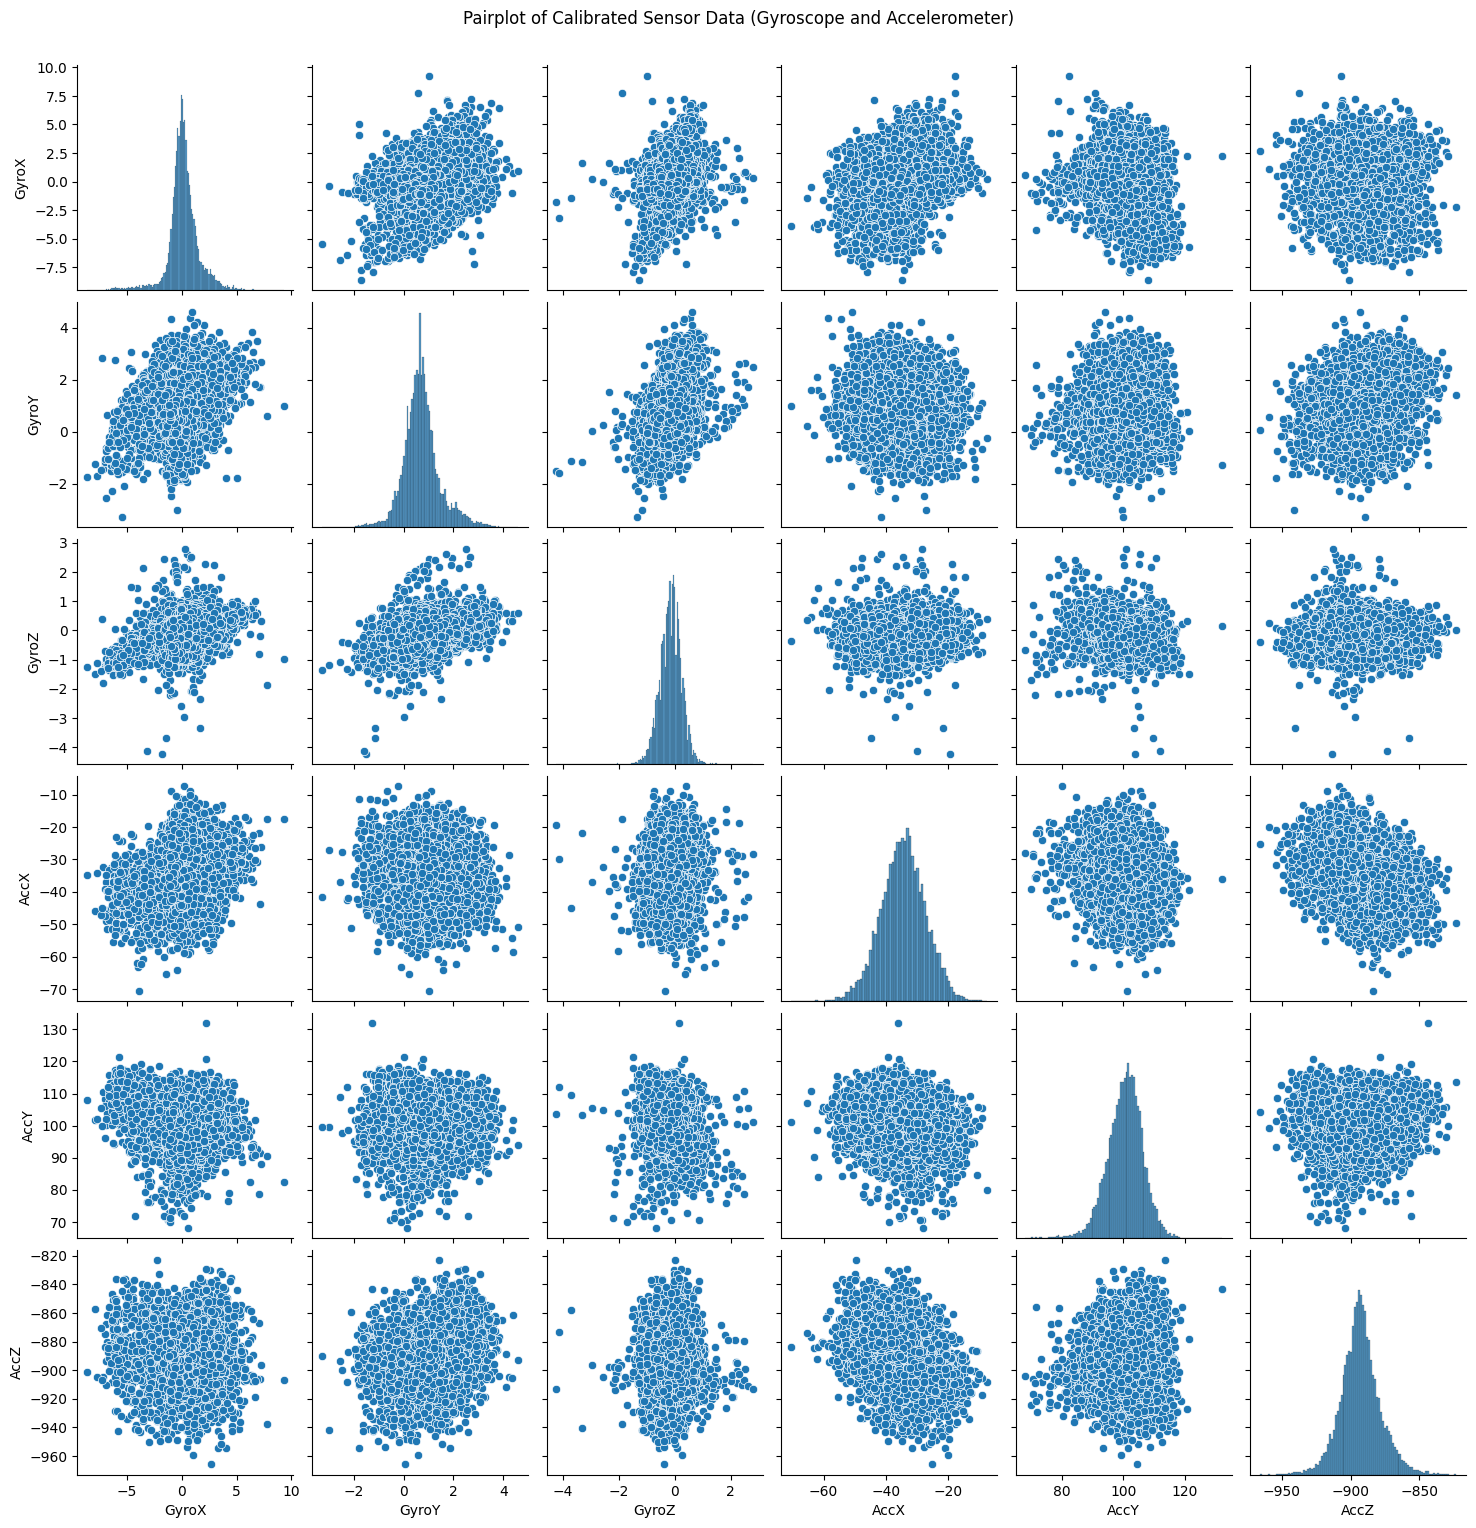

In [45]:
# do a seaborn.pairplot to see correlations between all the variables after calibration
import seaborn as sns
df_calibrated = pd.DataFrame({
    'Time': time,
    'GyroX': GyroArray[:, 0],
    'GyroY': GyroArray[:, 1],
    'GyroZ': GyroArray[:, 2],
    'AccX': AccArray[:, 0],
    'AccY': AccArray[:, 1],
    'AccZ': AccArray[:, 2],
    'MagnX': MagnArray[:, 0],
    'MagnY': MagnArray[:, 1],
    'MagnZ': MagnArray[:, 2]
})

sns.pairplot(df_calibrated.iloc[:, 1:7])  # Plot only a subset for clarity
plt.suptitle('Pairplot of Calibrated Sensor Data (Gyroscope and Accelerometer)', y=1.02)
plt.show()

Respiratory rate is from 0.16 to 0.33 Hz (less if at rest)

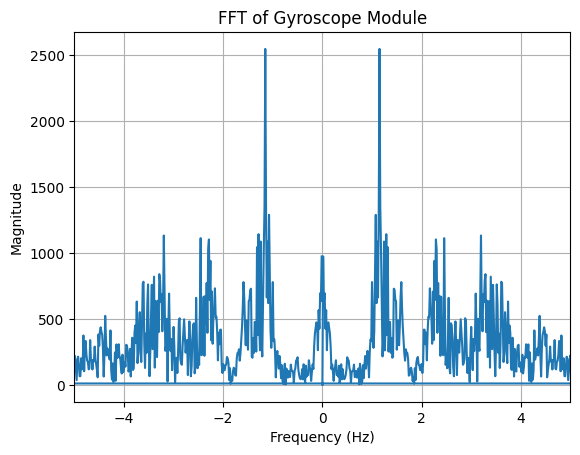

Respiratory Peak: 0.12 Hz (7.3 breaths/min)


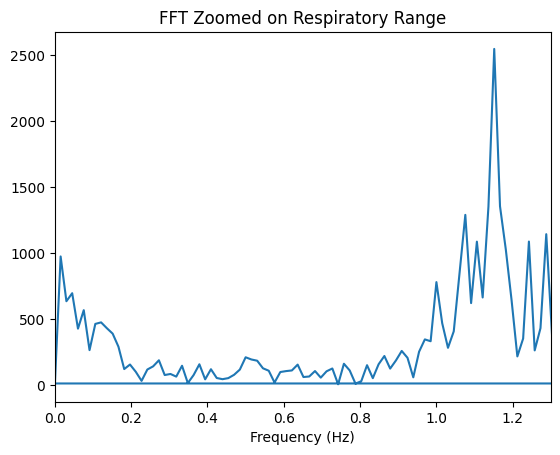

In [46]:
# point 2

from scipy.fft import fft, fftfreq, ifft
from scipy.signal import detrend

GyroModule_fft = fft(detrend(Gyro_module, type='constant'))
freq_GyroModule = fftfreq(len(Gyro_module), d=1/200)

# plot
plt.plot(freq_GyroModule, np.abs(GyroModule_fft))
plt.title('FFT of Gyroscope Module')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-5, 5)
plt.grid()
plt.show()

low_cut = 0.08 # Hz 
high_cut = 0.8

respiratory_mask = (freq_GyroModule >= low_cut) & (freq_GyroModule <= high_cut)

freqs_in_range = freq_GyroModule[respiratory_mask]
peak_freq_resp = freqs_in_range[np.argmax(np.abs(GyroModule_fft[respiratory_mask]))]
print(f'Respiratory Peak: {peak_freq_resp:.2f} Hz ({peak_freq_resp * 60:.1f} breaths/min)')

plt.plot(freq_GyroModule, np.abs(GyroModule_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT Zoomed on Respiratory Range')
plt.xlabel('Frequency (Hz)')
plt.show()

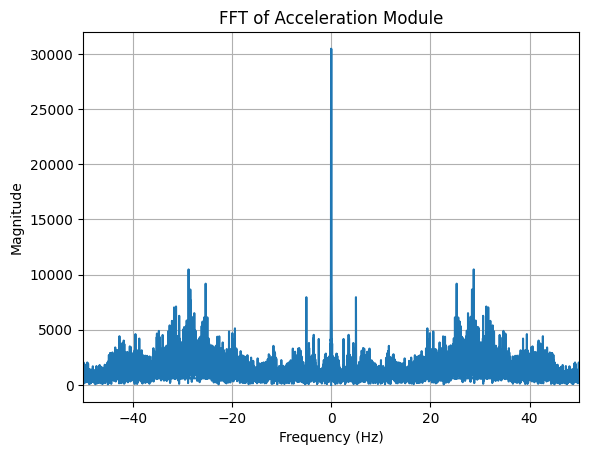

Respiratory Peak in Acceleration: 0.09 Hz (5.5 breaths/min)


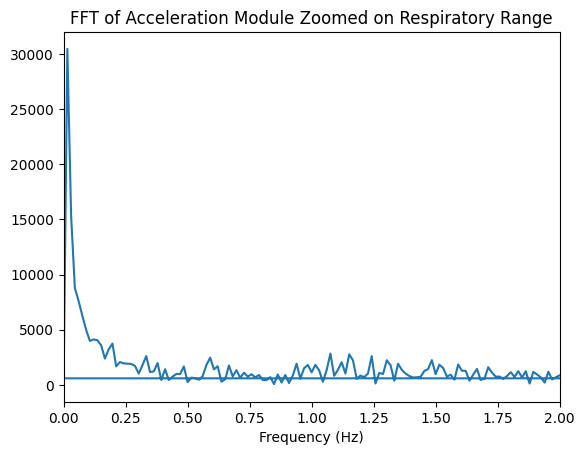

In [47]:
#  same with the acceleration module

AccModule_fft = fft(detrend(AccZ, type='constant'))
freq_AccModule = fftfreq(len(AccZ), d=1/200)
plt.plot(freq_AccModule, np.abs(AccModule_fft))
plt.title('FFT of Acceleration Module')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-50, 50)
plt.grid()
plt.show()

freqs_in_range_acc = freq_AccModule[respiratory_mask]
peak_freq_resp_acc = freqs_in_range_acc[np.argmax(np.abs(AccModule_fft[respiratory_mask]))]
print(f'Respiratory Peak in Acceleration: {peak_freq_resp_acc:.2f} Hz ({peak_freq_resp_acc * 60:.1f} breaths/min)')

plt.plot(freq_AccModule, np.abs(AccModule_fft))
plt.xlim(0, 2)
plt.title('FFT of Acceleration Module Zoomed on Respiratory Range')
plt.xlabel('Frequency (Hz)')
plt.show()

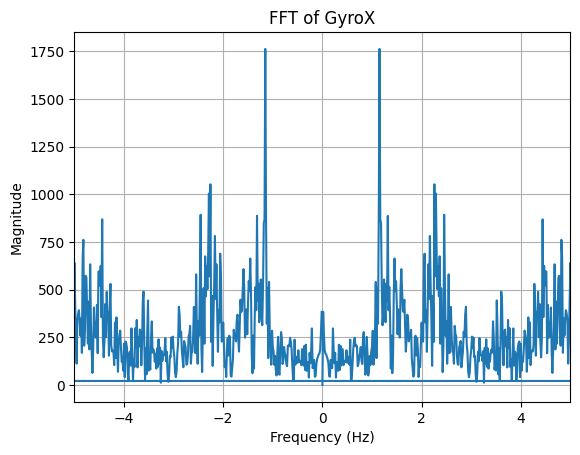

Respiratory Peak in GyroX: 0.21 Hz (12.7 breaths/min)


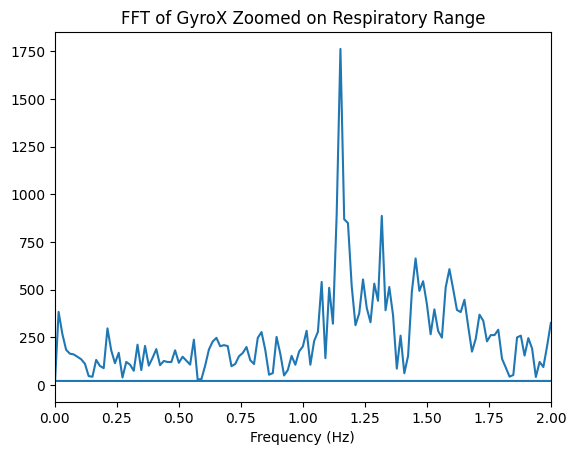

In [48]:
# fft on gyro x

GyroX_fft = fft(detrend(GyroX, type='constant'))
freq_GyroX = fftfreq(len(GyroX), d=1/200)
plt.plot(freq_GyroX, np.abs(GyroX_fft))
plt.title('FFT of GyroX')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-5, 5)
plt.grid()
plt.show()

freqs_in_range_gyroX = freq_GyroX[respiratory_mask]
peak_freq_resp_gyroX = freqs_in_range_gyroX[np.argmax(np.abs(GyroX_fft[respiratory_mask]))]
print(f'Respiratory Peak in GyroX: {peak_freq_resp_gyroX:.2f} Hz ({peak_freq_resp_gyroX * 60:.1f} breaths/min)')

plt.plot(freq_GyroX, np.abs(GyroX_fft))
plt.xlim(0, 2)
plt.title('FFT of GyroX Zoomed on Respiratory Range')
plt.xlabel('Frequency (Hz)')
plt.show()

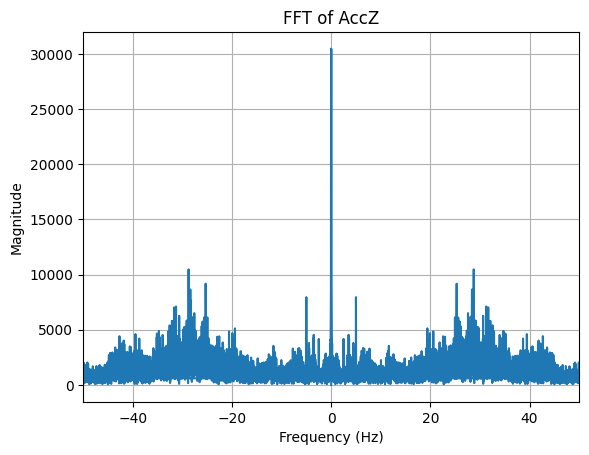

Respiratory Peak: 0.09 Hz (5.5 breaths/min)


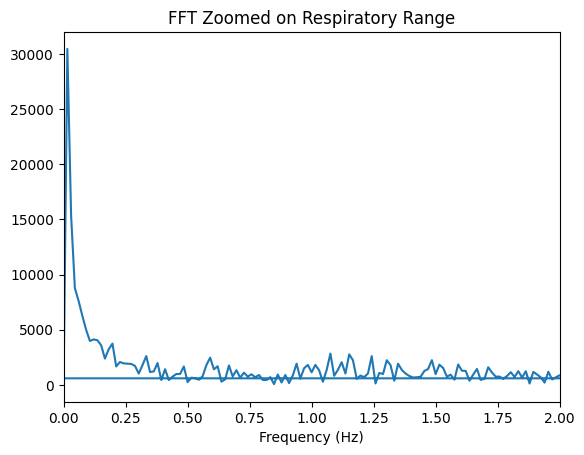

In [49]:
# fft on acc z

AccZ_fft = fft(detrend(AccZ, type='constant'))
freq_AccZ = fftfreq(len(AccZ), d=1/200)
plt.plot(freq_AccZ, np.abs(AccZ_fft))
plt.title('FFT of AccZ')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(-50, 50)
plt.grid()
plt.show()

respiratory_mask = (freq_AccZ >= low_cut) & (freq_AccZ <= high_cut)

freqs_in_range = freq_AccZ[respiratory_mask]
peak_freq_resp = freqs_in_range[np.argmax(np.abs(AccZ_fft[respiratory_mask]))]
print(f'Respiratory Peak: {peak_freq_resp:.2f} Hz ({peak_freq_resp * 60:.1f} breaths/min)')

plt.plot(freq_AccZ, np.abs(AccZ_fft))
plt.xlim(0, 2)
plt.title('FFT Zoomed on Respiratory Range')
plt.xlabel('Frequency (Hz)')
plt.show()